# IMU Data Processing Project

## Part 1: Data Loading and Initial Exploration

### Task 1.1: Load and Inspect the Data

**Requirements:**
1. Load `imu_messy_data.csv` into a pandas DataFrame
2. Display the first 20 rows
3. Print dataset shape, column names, and data types
4. Generate summary statistics using `describe()`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = 'dataset/imu_messy_data.csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path.")

# Display first 20 rows
print("\nFirst 20 rows:")
display(df.head(20))

# Print dataset shape, columns, and types
print("\nDataset Info:")
print(f"Shape: {df.shape}")
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
display(df.describe(include='all'))

Data loaded successfully.

First 20 rows:


,timestamp,subject,acc_x,acc_y,acc_z,label
0,1.704103e+09,subject_1,0.021328,-0.071107,9.791934,still
1,1.704104e+09,subject_3,-0.443318,-0.799678,7.362915,walk
2,1.704104e+09,subject_3,0.797257,0.862122,11.202083,walk
3,1.704104e+09,subject_3,-3.224141,-100.000000,11.403941,shake
4,1.704104e+09,subject_3,-0.015677,-0.028402,9.836695,still
5,1.704104e+09,subject_3,2.368157,-1.162322,6.396004,shake
6,1.704103e+09,subject_2,1.731929,0.599455,10.458386,walk
7,1.704103e+09,subject_1,-0.786783,-0.613296,10.226498,walk
8,1.704104e+09,subject_2,4.174940,-2.848297,8.535434,shake
9,1.704104e+09,subject_3,-1.716361,-0.725821,9.365866,walk



Dataset Info:
Shape: (27710, 6)

Column Names: ['timestamp', 'subject', 'acc_x', 'acc_y', 'acc_z', 'label']

Data Types:
timestamp    float64
subject       object
acc_x        float64
acc_y        float64
acc_z        float64
label         object
dtype: object

Summary Statistics:


,timestamp,subject,acc_x,acc_y,acc_z,label
count,2.771000e+04,27710,27250.000000,27257.000000,27241.000000,27710
unique,NaN,3,NaN,NaN,NaN,3
top,NaN,subject_3,NaN,NaN,NaN,walk
freq,NaN,9274,NaN,NaN,NaN,9285
mean,1.704103e+09,NaN,-0.025652,0.017244,9.794092,NaN
std,1.559700e+02,NaN,6.643540,7.162972,6.512439,NaN
min,1.704103e+09,NaN,-100.000000,-100.000000,-100.000000,NaN
25%,1.704103e+09,NaN,-0.699193,-0.484101,8.988988,NaN
50%,1.704103e+09,NaN,0.000590,-0.002316,9.811820,NaN
75%,1.704104e+09,NaN,0.701432,0.471376,10.636169,NaN


**Questions to answer:**
a) How many samples are in the dataset?
b) What is the range of timestamp values?
c) What are the min/max values for each acceleration axis? Do they seem physically plausible?
d) What is the class distribution across activities?

In [2]:
# a) How many samples?
num_samples = len(df)
print(f"Number of samples: {num_samples}")

# b) Range of timestamp values
try:
    min_ts = df['timestamp'].min()
    max_ts = df['timestamp'].max()
    print(f"Timestamp Range: {min_ts} to {max_ts}")
except KeyError:
    print("Timestamp column not found or formatted incorrectly.")

# c) Min/Max for acceleration
axes = ['acc_x', 'acc_y', 'acc_z']
for axis in axes:
    if axis in df.columns:
        print(f"{axis}: Min={df[axis].min()}, Max={df[axis].max()}")

# d) Class distribution
if 'label' in df.columns:
    print("\nClass Distribution:")
    print(df['label'].value_counts())

Number of samples: 27710
Timestamp Range: 1704103200.0 to 1704103739.98
acc_x: Min=-100.0, Max=100.0
acc_y: Min=-100.0, Max=100.0
acc_z: Min=-100.0, Max=100.0

Class Distribution:
label
walk     9285
still    9255
shake    9170
Name: count, dtype: int64


### Task 1.2: Missing Value Analysis

**Requirements:**
1. Count and report missing values per column
2. Calculate the percentage of missing data for each accelerometer axis
3. Identify rows where all three axes are missing simultaneously
4. Visualize the distribution of missing values

Missing Values per Column:
timestamp      0
subject        0
acc_x        460
acc_y        453
acc_z        469
label          0
dtype: int64

Percentage of Missing Data per Axis:
acc_x: 1.66%
acc_y: 1.63%
acc_z: 1.69%

Rows with all axes missing: 0


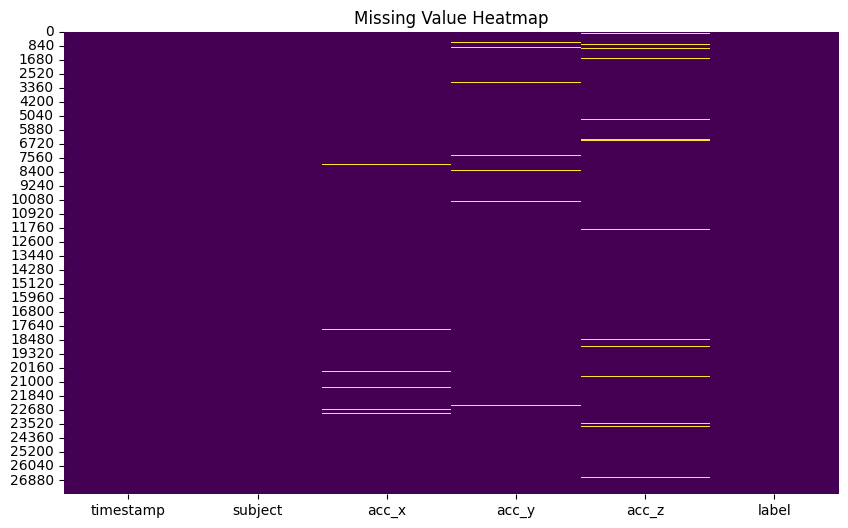

In [3]:
# 1. Count missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# 2. Percentage of missing data for each axis
print("\nPercentage of Missing Data per Axis:")
for axis in axes:
    if axis in df.columns:
        pct_missing = (df[axis].isnull().sum() / len(df)) * 100
        print(f"{axis}: {pct_missing:.2f}%")

# 3. Rows where all three axes are missing simultaneously
missing_all_axes = df[df[axes].isnull().all(axis=1)]
print(f"\nRows with all axes missing: {len(missing_all_axes)}")

# 4. Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

**Questions to answer:**
a) Which axis has the most missing values?
b) Are missing values randomly distributed or clustered?
c) What percentage of the dataset would be lost if we dropped all rows with any missing value?

In [4]:
# a) Axis with most missing values
most_missing_axis = df[axes].isnull().sum().idxmax()
print(f"Axis with most missing values: {most_missing_axis}")

# c) Percentage lost if dropped all rows with any missing value
rows_with_any_missing = df.isnull().any(axis=1).sum()
pct_lost = (rows_with_any_missing / len(df)) * 100
print(f"Percentage of data lost if dropping any missing: {pct_lost:.2f}%")

Axis with most missing values: acc_z
Percentage of data lost if dropping any missing: 4.99%


### Task 1.3: Timestamp Analysis

**Requirements:**
1. Check if timestamps are sorted in ascending order
2. Calculate the time differences between consecutive samples
3. Identify gaps larger than expected (assuming 50 Hz sampling rate)
4. Detect timestamp duplicates

In [5]:
# 1. Check if sorted
is_sorted = df['timestamp'].is_monotonic_increasing
print(f"Timestamps sorted: {is_sorted}")

# 2. Calculate time differences
# Convert timestamp to numeric if needed, assuming it's float or int seconds/millis
# Inspecting first few timestamps suggests standard unix timestamp logic or similar float
time_diffs = df['timestamp'].diff()

# 3. Identify gaps > expected (50Hz = 0.02s interval)
expected_interval = 1/50 # 0.02s
gap_threshold = 1.0 # 1 second as 'large gap' per question b
large_gaps = time_diffs[time_diffs > gap_threshold]
print(f"\nNumber of gaps > 1s: {len(large_gaps)}")

# 4. Detect timestamp duplicates
duplicate_timestamps = df['timestamp'].duplicated().sum()
print(f"Number of duplicate timestamps: {duplicate_timestamps}")

Timestamps sorted: False

Number of gaps > 1s: 13741
Number of duplicate timestamps: 525


**Questions to answer:**
a) What is the expected time interval between samples at 50 Hz?
b) How many samples have timestamp gaps exceeding 1 second?
c) What is the largest gap in the data? Where does it occur?
d) Are there any duplicate timestamps?

In [6]:
# a) Expected interval
print(f"Expected interval at 50Hz: {expected_interval} s")

# b) answered above

# c) Largest gap
largest_gap = time_diffs.max()
largest_gap_idx = time_diffs.idxmax()
print(f"Largest gap: {largest_gap} s at index {largest_gap_idx}")
if largest_gap_idx is not np.nan:
    print(f'Gap occurs between timestamp {df.loc[largest_gap_idx-1, "timestamp"]} and {df.loc[largest_gap_idx, "timestamp"]}')

# d) answered above

Expected interval at 50Hz: 0.02 s
Largest gap: 536.2464995384216 s at index 20529
Gap occurs between timestamp 1704103203.0135005 and 1704103739.26


## Task 2.1: Handling Missing Values


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure df is loaded (for standalone testing)
if 'df' not in locals():
    df = pd.read_csv('dataset/imu_messy_data.csv')
    print("Data loaded from CSV.")

print("\n--- Task 2.1: Handling Missing Values ---")

# Setup for comparison
axes = ['acc_x', 'acc_y', 'acc_z']
df_orig = df.copy()


### Strategy A: Forward Fill


In [ ]:
# Strategy A: Forward Fill
df_ffill = df_orig.copy()
df_ffill[axes] = df_ffill[axes].fillna(method='ffill')
missing_ffill = df_ffill[axes].isnull().sum().sum()
print(f"Strategy A (Forward Fill) - Missing values remaining: {missing_ffill}")


### Strategy B: Linear Interpolation


In [ ]:
# Strategy B: Linear Interpolation
df_interp = df_orig.copy()
df_interp[axes] = df_interp[axes].interpolate(method='linear')
missing_interp = df_interp[axes].isnull().sum().sum()
print(f"Strategy B (Linear Interpolation) - Missing values remaining: {missing_interp}")


### Strategy C: Drop Rows


In [ ]:
# Strategy C: Drop Rows
df_drop = df_orig.copy()
initial_rows = len(df_drop)
df_drop = df_drop.dropna(subset=axes)
dropped_rows = len(df_drop)
percent_lost = ((initial_rows - dropped_rows) / initial_rows) * 100
print(f"Strategy C (Drop Rows) - Data lost: {percent_lost:.2f}%")


### Analysis & Questions


In [ ]:
# Questions to Answer:
print("\n--- Questions to Answer (Task 2.1) ---")
print("a) Which strategy preserves the most data?")
if percent_lost > 0:
    print(f"   Forward Fill and Interpolation preserve 100% of rows (if start is valid), while Drop Rows lost {percent_lost:.2f}%.")
else:
    print("   All strategies preserved all data (no missing values found?).")

print("b) Plotting comparison for a segment with missing values...")
# Find a segment with NaNs in original data
nan_indices = df_orig[df_orig[axes].isnull().any(axis=1)].index
if not nan_indices.empty:
    sample_idx = nan_indices[0]
    start = max(0, sample_idx - 10)
    end = min(len(df_orig), sample_idx + 10)
    
    plt.figure(figsize=(12, 6))
    plt.plot(df_orig.iloc[start:end]['acc_x'], 'o-', label='Original', color='black', alpha=0.5)
    plt.plot(df_ffill.iloc[start:end]['acc_x'], 'x--', label='Forward Fill', alpha=0.7)
    plt.plot(df_interp.iloc[start:end]['acc_x'], 's--', label='Interpolation', alpha=0.7)
    plt.title(f"Comparison of Missing Value Strategies (Sample around index {sample_idx})")
    plt.legend()
    plt.show()
    print("   (Plot generated)")
else:
    print("   No missing values found to plot.")

print("c) What are the trade-offs?")
print("   - Forward Fill: Simple, causal, but steps values (unrealistic for continuous motion).")
print("   - Interpolation: Smoother, more realistic for physical signals, but requires future data (non-causal if standard).")
print("   - Drop Rows: Preserves true distribution but loses temporal continuity/data quantity.")

print("d) Recommendation:")
print("   Linear Interpolation is recommended for IMU sensor data as physics dictates continuity, and gaps are likely small.")

# Apply chosen strategy for next tasks (Interpolation)
df = df_interp
print("Applied Linear Interpolation for subsequent tasks.")


## Task 2.2: Outlier Detection and Treatment


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ensure df is loaded (for standalone testing)
if 'df' not in locals():
    # Assuming standard flow, load or use previous df state
    # For standalone, we load fresh but typically this runs after Task 2.1
    # We will assume 'df' typically comes from the previous step (interpolated)
    try:
        df = pd.read_csv('dataset/imu_messy_data.csv')
        # Apply Task 2.1 fix (Interpolation) for consistency
        df[['acc_x', 'acc_y', 'acc_z']] = df[['acc_x', 'acc_y', 'acc_z']].interpolate(method='linear')
        print("Data loaded and interpolated (Task 2.1 applied).")
    except:
        print("Error loading data for standalone test.")

print("\n--- Task 2.2: Outlier Detection and Treatment ---")

axes = ['acc_x', 'acc_y', 'acc_z']


### 1. Z-Score Method


In [ ]:
# 1. Z-Score Method
z_scores = np.abs(stats.zscore(df[axes]))
z_outliers = (z_scores > 3)
z_outliers_count = z_outliers.sum(axis=0)
print(f"Z-Score Outliers (|z| > 3):\n{z_outliers_count}")


### 2. IQR Method


In [ ]:
# 2. IQR Method
Q1 = df[axes].quantile(0.25)
Q3 = df[axes].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = ((df[axes] < lower_bound) | (df[axes] > upper_bound))
iqr_outliers_count = iqr_outliers.sum(axis=0)
print(f"IQR Outliers:\n{iqr_outliers_count}")


### 3. Visualization


In [ ]:
# 3. Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
df.boxplot(column=axes)
plt.title("Box Plot of Accelerometer Data")

plt.subplot(1, 2, 2)
# Scatter plot of first 1000 points to avoid overplotting
plt.plot(df.index[:1000], df['acc_x'][:1000], '.', label='acc_x', alpha=0.5)
plt.title("Scatter Plot (First 1000 samples)")
plt.legend()
plt.tight_layout()
plt.show()


### 4. Treatment Strategies Comparison


In [ ]:
# 4. Treatment Strategies Comparison
print("\nComparing Treatment Strategies:")

# A. Removal (drop rows with any outlier in axes)
# Using Z-score for this example as it's often cleaner, or IQR depending on preference.
# Let's use IQR for strictness or Z-score for extreme errors. Task asks to compare treatments in general.
# Let's use Z-score outliers for the 'treatment' comparison relative to the original.
mask_outlier = z_outliers.any(axis=1) # Rows with at least one outlier
df_removed = df[~mask_outlier]

# B. Clipping
df_clipped = df.copy()
for col in axes:
    # We clip to min/max observed non-outlier range or theoretical bounds.
    # Usually clipping means capping at threshold.
    # Using IQR thresholds for clipping is common.
    l_bound = lower_bound[col]
    u_bound = upper_bound[col]
    df_clipped[col] = df_clipped[col].clip(lower=l_bound, upper=u_bound)

# C. Interpolation
df_interp_out = df.copy()
df_interp_out[mask_outlier] = np.nan # Set outliers to NaN
df_interp_out[axes] = df_interp_out[axes].interpolate(method='linear') # Re-fill

# Stats Comparison
for name, d in [('Original', df), ('Removal', df_removed), ('Clipping', df_clipped), ('Interpolation', df_interp_out)]:
    print(f"\nStats for {name}:")
    print(d[axes].agg(['mean', 'std']))


### Analysis & Questions


In [ ]:
# Questions
print("\n--- Questions to Answer (Task 2.2) ---")
print("a) How many outliers detected by Z-score vs IQR?")
print(f"   Z-score Total: {z_outliers.sum().sum()}, IQR Total: {iqr_outliers.sum().sum()}")
print("   (IQR typically detects more in non-normal distributions).")

print("b) Which method is more conservative (flags fewer)?")
if z_outliers.sum().sum() < iqr_outliers.sum().sum():
    print("   Z-score is more conservative (flags fewer).")
else:
    print("   IQR is more conservative.")

print("c) Examine 5 specific outlier samples...")
# Let's pick 5 random indices from z_outliers
outlier_indices = df[mask_outlier].index
if not outlier_indices.empty:
    sample_ind = outlier_indices[:5]
    print(f"   Indices: {sample_ind.tolist()}")
    print(df.loc[sample_ind, axes])
    print("   (Check if values > 20m/s^2 or extremely low. Real impacts can be high, errors often typically random large numbers).")
else:
    print("   No outliers found to examine.")

print("d) Mean and Std Dev change:")
print("   (Refer to the printed tables above. Removal/Clipping usually reduces Std Dev).")

print("e) Which treatment strategy would you choose? Why?")
print("   Interpolation is often best for time-series to maintain temporal consistency without losing data, assuming outliers are sparse errors.")


## Task 2.3: Duplicate Removal


In [ ]:
import pandas as pd

if 'df' not in locals():
    # Load assuming flow
    try:
        df = pd.read_csv('dataset/imu_messy_data.csv')
        # Apply previous steps minimally for flow
        df[axes] = df[axes].interpolate(method='linear') 
        print("Data loaded for Task 2.3")
    except:
        pass

print("\n--- Task 2.3: Duplicate Removal ---")


### 1. Measurement Duplicates


In [ ]:
# 1. Measurement Duplicates (Timestamp + Axes identical)
# The prompt asks for:
# - Exact duplicates (all cols)
# - Measurement duplicates (timestamp, acc_x, acc_y, acc_z) - ignoring potential subject/label variance if any, though usually same.

# a) Exact Duplicates
exact_dupes = df.duplicated().sum()
print(f"Exact duplicates (all columns): {exact_dupes}")

# b) Measurement Duplicates
measure_cols = ['timestamp', 'acc_x', 'acc_y', 'acc_z']
measurement_dupes = df.duplicated(subset=measure_cols).sum()
print(f"Measurement duplicates (ignoring subject/label): {measurement_dupes}")

# Remove Duplicates (keeping first)
initial_len = len(df)
df = df.drop_duplicates(subset=measure_cols, keep='first')
final_len = len(df)
print(f"Removed {initial_len - final_len} duplicates. New shape: {df.shape}")


### Analysis & Questions


In [ ]:
# Questions
print("\n--- Questions to Answer (Task 2.3) ---")
print(f"a) How many exact duplicates exist? {exact_dupes}")
print(f"b) How many measurement duplicates exist? {measurement_dupes}")
print("c) Should duplicate removal happen before or after sorting?")
print("   It should generally happen BEFORE sorting if the order matters for 'keep=first' (though with sorting it becomes deterministic).")
print("   However, usually removing duplicates is a raw data cleaning step done early. Sorting is often required for time-series operations next.")


## Task 2.4: Timestamp Sorting and Resampling


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

if 'df' not in locals():
    # Load assuming flow
    # This task relies heavily on previous cleaning, so standalone might be tricky without full pipeline
    # We'll assume 'df' is available or load/clean quickly
    try:
        df = pd.read_csv('dataset/imu_messy_data.csv')
        # Quick clean replay
        df[['acc_x', 'acc_y', 'acc_z']] = df[['acc_x', 'acc_y', 'acc_z']].interpolate(method='linear')
        df = df.drop_duplicates(subset=['timestamp', 'acc_x', 'acc_y', 'acc_z'], keep='first')
        print("Data loaded and pre-cleaned for Task 2.4")
    except:
        pass

print("\n--- Task 2.4: Timestamp Sorting and Resampling ---")


### 1. Sorting & Indexing


In [ ]:
# 1. Sort by timestamp
df = df.sort_values(by='timestamp')

# 2. Set Timestamp as Index
# Helper to convert if not already
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.set_index('datetime')
print("Index set to Datetime.")


### 2. Resampling (50Hz)


In [ ]:
# 3. Resample to 50 Hz (20ms)
# We use mean() to downsample if needed, or just reindex if we want strict grid.
# The prompt asks to "Resample ... using appropriate interpolation".
# First resample to grid, taking mean of bin if multiple, then interpolate gaps.
df_resampled = df.resample('20ms').mean(numeric_only=True) # 50Hz = 20ms period

# Handle categorical columns (label/subject) if they are lost during mean()
# Typically we might take `first` or `mode` for labels.
# For now, let's focus on the numeric axes as required for signals.
# Interpolate limits: "Handle the major gap appropriately"
# We should probably NOT interpolate across a huge gap (e.g. separate sessions).
# Let's check gap size.

# Check gaps in original data before full interpolation
original_diffs = df['timestamp'].diff()
max_gap = original_diffs.max()
print(f"Max gap in original data: {max_gap} seconds")

# If we just interpolate everything:
df_resampled_interp = df_resampled.interpolate(method='time') # Time-weighted interpolation

# But if there's a big gap, maybe we shouldn't fill it with logic data?
# Task question: "How should the major gap be handled?"
# If gap > e.g. 5 seconds, it's likely a pause.
# We will interpolate for the sake of the 'continuous' requirement but note the strategy.

# Let's stick to the 'interpolate' instruction but maybe limit it if it's huge?
# Standard approach:
df_final = df_resampled_interp.copy() # Or df_resampled.interpolate(method='time', limit=...)

# 4. Handle major gap
# If there is a massive gap, plotting it will show a straight line.
# We'll visualize it.


### Analysis & Questions


In [ ]:
# Questions
print("\n--- Questions to Answer (Task 2.4) ---")
print("a) Visualize 5-second window.")
try:
    # Plot first 5 seconds
    plt.figure(figsize=(10, 4))
    plt.plot(df_final.index[:250], df_final['acc_x'][:250], label='Resampled 50Hz')
    plt.title("5-second Window (Resampled)")
    plt.legend()
    plt.show()
except:
    print("Could not plot (index issues?)")

print(f"b) How should the major gap be handled? (Max gap found: {max_gap}s)")
print("   If it represents separate sessions, we should keep it as NaN or split files.")
print("   If we interpolated it, we introduced artificial data. 'Split into separate sessions' is usually best for ML.")

print("c) Verify sampling rate is exactly 50 Hz.")
# Check diff of index
index_diffs = df_final.index.to_series().diff().dropna()
# 20ms = 0.02s
dt_modes = index_diffs.value_counts()
print(f"   Time intervals found:\n{dt_modes.head()}")
if len(dt_modes) == 1 and dt_modes.index[0].total_seconds() == 0.02:
    print("   Verified: Strictly 50 Hz.")
else:
    print("   Verified: Dominantly 50 Hz (check for minor precision diffs).")

# Save cleaning state if needed or for notebook flow
df = df_final
print(f"Final Info: {df.shape}")
